In [11]:
import sys
from pathlib import Path
import pandas as pd
import seaborn as sns
from config import DATA_PATHS

PROJECT_ROOT = Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

ft_stats = pd.read_csv(DATA_PATHS["stats_dir"] / "fighter_stats.csv")

ft_stats.head()

,name,wins,losses,height,weight,reach,stance,age,SLpM,sig_str_acc,SApM,str_def,td_avg,td_acc,td_def,sub_avg
0,Amanda Ribas,12.0,5.0,160.02,56.70,167.64,Orthodox,30.0,4.63,0.40,3.40,0.61,2.07,0.51,0.85,0.7
1,Rose Namajunas,13.0,6.0,165.10,56.70,165.10,Orthodox,31.0,3.69,0.41,3.51,0.63,1.38,0.47,0.59,0.5
2,Karl Williams,10.0,1.0,190.50,106.59,200.66,Orthodox,34.0,2.87,0.52,1.70,0.60,4.75,0.50,1.00,0.2
3,Justin Tafa,7.0,4.0,182.88,119.75,187.96,Southpaw,30.0,4.09,0.54,5.02,0.47,0.00,0.00,0.50,0.0
4,Edmen Shahbazyan,13.0,4.0,187.96,83.91,190.50,Orthodox,26.0,3.60,0.52,4.09,0.45,2.24,0.38,0.63,0.6


In [4]:
ft_stats.describe()

,wins,losses,height,weight,reach,age,SLpM,sig_str_acc,SApM,str_def,td_avg,td_acc,td_def,sub_avg
count,2478.000000,2478.000000,2478.000000,2478.000000,1823.000000,2318.000000,2478.000000,2478.000000,2478.000000,2478.000000,2478.000000,2478.000000,2478.000000,2478.000000
mean,14.399112,6.111380,178.384262,76.876852,182.035656,37.727783,2.932623,0.406029,3.388567,0.488910,1.393543,0.322571,0.494972,0.602179
std,9.853474,4.548011,8.851777,17.976646,10.654129,7.251188,1.736693,0.151297,2.027258,0.162305,1.512821,0.256928,0.297551,1.057863
min,0.000000,0.000000,152.400000,52.160000,147.320000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,3.000000,172.720000,65.770000,175.260000,32.000000,1.810000,0.360000,2.320000,0.450000,0.120000,0.070000,0.300000,0.000000
50%,13.000000,5.000000,177.800000,77.110000,182.880000,37.000000,2.900000,0.430000,3.230000,0.520000,1.000000,0.330000,0.550000,0.300000
75%,18.000000,8.000000,185.420000,83.910000,190.500000,42.000000,3.920000,0.500000,4.290000,0.580000,2.065000,0.480000,0.710000,0.800000
max,253.000000,53.000000,210.820000,349.270000,213.360000,81.000000,23.330000,1.000000,42.000000,1.000000,13.950000,1.000000,1.000000,16.400000


In [6]:
ft_stats.isna().sum()

name             1
wins             1
losses           1
height           1
weight           1
reach          656
stance          78
age            161
SLpM             1
sig_str_acc      1
SApM             1
str_def          1
td_avg           1
td_acc           1
td_def           1
sub_avg          1
dtype: int64

In [7]:
print(ft_stats.columns)

Index(['name', 'wins', 'losses', 'height', 'weight', 'reach', 'stance', 'age',
       'SLpM', 'sig_str_acc', 'SApM', 'str_def', 'td_avg', 'td_acc', 'td_def',
       'sub_avg'],
      dtype='str')


In [ ]:
# fill the reaches with group mean imputation
ft_stats["imputed_reach"] = ft_stats.groupby(['height', 'reach'])['reach'].transform('mean')
ft_stats['reach'] = ft_stats['imputed_reach'].fillna(ft_stats['imputed_reach'])

ft_stats['reach']
# I need some baseline to identify each of the fighter's reaches, since these reaches are really important, especially for strikers

0       167.64
1       165.10
2       200.66
3       187.96
4       190.50
         ...  
2474       NaN
2475       NaN
2476       NaN
2477       NaN
2478       NaN
Name: reach, Length: 2479, dtype: float64

<Axes: ylabel='reach'>

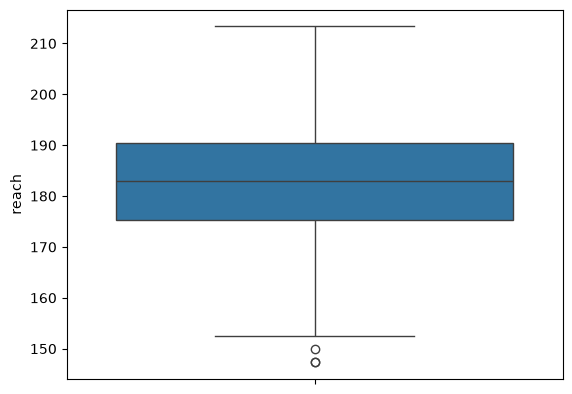

In [13]:
sns.boxplot(ft_stats["reach"])
# one more check